# Flavor Ratio Extraction from SIDIS Data

Extract $D^-/D^+$ from deuterium SIDIS data and use it to extract $d/u$ from proton SIDIS data.

Uses the histogram loading formalism from `plotRatioBinned3D.ipynb`.

In [282]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import os
import argparse
import sys

## 1. Configuration

In [283]:
# ── Input ROOT files ─────────────────────────────────────────────────────────
DEUT_FILE = "../histograms/analysis_note/ratios_2d_rho.root"
PROT_FILE = "../histograms/analysis_note/ratios_2d_rho_rga.root"

# ── Correction level ─────────────────────────────────────────────────────────
# > 3: apply kaon correction (hRatio_k present)
# > 4: apply rho correction  (hRatio_r present)
APPLY_CORR = 3

# ── Kinematic bin definitions (must match cut_values.h) ──────────────────────
BINS_VAR = 1
BINS_Q2  = 12;  Q2_MIN, Q2_MAX = 4.0, 8.0
BINS_XB  = 14;  XB_MIN, XB_MAX = 0.1, 0.66
BINS_Z   = 14

# ── Summation options ────────────────────────────────────────────────────────
#   False       : keep each bin separate
#   True        : sum over all bins in that dimension
#   (lo, hi)    : sum only over bins whose range overlaps [lo, hi]
SUM_VAR = False
SUM_Q2  = True
SUM_XB  = False    # set to False or (lo, hi) tuple for xB-differential d/u

# ── Variable info (when BINS_VAR > 1) ────────────────────────────────────────
VAR_LABEL = r'$M_X$'
VAR_MIN   = 1.7
VAR_MAX   = 6.7
VAR_UNIT  = 'GeV'

# ── Output directory (None = display inline only) ────────────────────────────
OUT_DIR = None  # e.g. "flavor_plots"

# ── Parse command-line arguments (when run as a script) ──────────────────────
# In notebook mode these are ignored; override the variables above instead.
if not hasattr(sys, 'ps1') and '__file__' in dir():
    parser = argparse.ArgumentParser(
        description='Extract D-/D+ and d/u from SIDIS data'
    )
    parser.add_argument('--deut', type=str, default=DEUT_FILE,
                        help='Path to deuterium ROOT file')
    parser.add_argument('--prot', type=str, default=PROT_FILE,
                        help='Path to proton ROOT file')
    parser.add_argument('--apply-corr', type=int, default=APPLY_CORR,
                        help='Correction level (>3: kaon, >4: rho)')
    parser.add_argument('--out-dir', type=str, default=OUT_DIR,
                        help='Output directory for plots')
    args = parser.parse_args()
    DEUT_FILE  = args.deut
    PROT_FILE  = args.prot
    APPLY_CORR = args.apply_corr
    OUT_DIR    = args.out_dir

## 2. Shared Helper Functions

In [284]:
def get_hist(f, name):
    """Return (values, errors, bin_centers) or None if histogram absent."""
    key = name + ";1"
    if key not in f:
        if name not in f:
            return None
        key = name
    h = f[key]
    edges = h.axis().edges()
    centers = (edges[:-1] + edges[1:]) / 2
    return np.array(h.values()), np.array(h.errors()), centers


def ratio_hists(num_v, num_e, den_v, den_e):
    """Element-wise ratio num/den with propagated errors."""
    with np.errstate(invalid='ignore', divide='ignore'):
        r = np.where(den_v != 0, num_v / den_v, np.nan)
        r_e = np.where(
            (den_v != 0) & (num_v != 0),
            np.abs(r) * np.sqrt((num_e / num_v)**2 + (den_e / den_v)**2),
            np.nan
        )
    return r, r_e


def detect_naming_style(f, bins_q2, bins_xb):
    """
    Auto-detect histogram naming convention in a ROOT file.
    Returns (name_style, file_bins_var) where name_style is one of:
      'new_multi'  : hRatio_{var}_{Q2}_{xB}_{charge+1}
      'new_single' : hRatio_{var}_{Q2}_{xB}
      'old'        : hRatio_{Q2}_{xB}
    """
    def _probe(name):
        return (name + ";1") in f or name in f

    def _probe_any(pattern_fn):
        for q in range(1, bins_q2 + 1):
            for x in range(1, bins_xb + 1):
                if _probe(pattern_fn(q, x)):
                    return True
        return False

    if _probe_any(lambda q, x: f"hRatio_0_{q}_{x}_1"):
        style = "new_multi"
        file_bins_var = 0
        while _probe_any(lambda q, x: f"hRatio_{file_bins_var}_{q}_{x}_1"):
            file_bins_var += 1
        return style, file_bins_var
    elif _probe_any(lambda q, x: f"hRatio_0_{q}_{x}"):
        return "new_single", 1
    elif _probe_any(lambda q, x: f"hRatio_{q}_{x}"):
        return "old", 1
    else:
        all_keys = [k.split(";")[0] for k in f.keys()]
        ratio_keys = [k for k in all_keys if k.startswith("hRatio")][:10]
        raise RuntimeError(
            f"Cannot detect histogram naming convention.\n"
            f"Sample hRatio* keys in file: {ratio_keys}"
        )


def make_hist_name(name_style, prefix, var, charge_str, q_idx, x_idx):
    """Build histogram name matching the auto-detected naming style."""
    if name_style == "new_multi":
        charge_k = 0 if charge_str == '' else 1
        return f"{prefix}_{var}{charge_str}_{q_idx+1}_{x_idx+1}_{charge_k+1}"
    elif name_style == "new_single":
        return f"{prefix}_{var}{charge_str}_{q_idx+1}_{x_idx+1}"
    else:  # old
        return f"{prefix}{charge_str}_{q_idx+1}_{x_idx+1}"

## 3. Cross-Section Loading Function

In [285]:
def load_cross_sections(filepath, apply_corr, bins_var, bins_q2, bins_xb, bins_z):
    """
    Load pi+ and pi- yields from a ROOT file produced by makeRatioBinned3D.

    Parameters
    ----------
    filepath : str
        Path to the ROOT file.
    apply_corr : int
        Correction level (>3: add kaon, >4: subtract rho).
    bins_var, bins_q2, bins_xb, bins_z : int
        Number of bins in each dimension.

    Returns
    -------
    pip_v, pip_e, pim_v, pim_e : ndarray of shape (bins_var, bins_q2, bins_xb, bins_z)
        Pi+ and pi- yield values and errors.
    z_centers : ndarray
        Bin centres along the z axis.
    actual_bins_var : int
        Number of var bins actually found in the file.
    """
    f = uproot.open(filepath)

    # Detect naming convention
    name_style, file_bins_var = detect_naming_style(f, bins_q2, bins_xb)
    actual_bins_var = file_bins_var if file_bins_var != 0 else bins_var
    if name_style == "new_single":
        actual_bins_var = bins_var
    print(f"  [{os.path.basename(filepath)}] naming='{name_style}', "
          f"var bins in file={actual_bins_var}")

    # Allocate 4-D arrays
    shape = (actual_bins_var, bins_q2, bins_xb, bins_z)
    pip_v = np.full(shape, np.nan)
    pip_e = np.full(shape, np.nan)
    pim_v = np.full(shape, np.nan)
    pim_e = np.full(shape, np.nan)
    z_cen = None

    def hn(prefix, var, charge_str, q, x):
        return make_hist_name(name_style, prefix, var, charge_str, q, x)

    for var in range(actual_bins_var):
        for q in range(bins_q2):
            for x in range(bins_xb):
                # Load base pi+ and pi- yields
                pip = get_hist(f, hn('hRatio', var, '',     q, x))
                pim = get_hist(f, hn('hRatio', var, '_Pim', q, x))
                if pip is None or pim is None:
                    continue

                pv, pe, cen = pip
                mv, me, _   = pim
                if z_cen is None:
                    z_cen = cen

                # Kaon correction: add kaon yields
                if apply_corr > 3:
                    for prefix, charge in [('hRatio_k', ''), ('hRatio_k', '_Pim')]:
                        k = get_hist(f, hn(prefix, var, charge, q, x))
                        if k is not None:
                            if charge == '':
                                pv = pv + k[0]
                                pe = np.sqrt(pe**2 + k[1]**2)
                            else:
                                mv = mv + k[0]
                                me = np.sqrt(me**2 + k[1]**2)

                # Rho correction: subtract rho yields
                if apply_corr > 4:
                    for prefix, charge in [('hRatio_r', ''), ('hRatio_r', '_Pim')]:
                        r = get_hist(f, hn(prefix, var, charge, q, x))
                        if r is not None:
                            if charge == '':
                                pv = pv - r[0]
                                pe = np.sqrt(pe**2 + r[1]**2)
                            else:
                                mv = mv - r[0]
                                me = np.sqrt(me**2 + r[1]**2)

                pip_v[var, q, x] = pv
                pip_e[var, q, x] = pe
                pim_v[var, q, x] = mv
                pim_e[var, q, x] = me

    n_loaded = int(np.sum(np.any(np.isfinite(pip_v), axis=-1)))
    print(f"  Loaded {n_loaded} / {actual_bins_var * bins_q2 * bins_xb} "
          f"(var x Q2 x xB) bins.")
    if z_cen is None:
        raise RuntimeError(f"No histograms loaded from {filepath} — check path.")

    return pip_v, pip_e, pim_v, pim_e, z_cen, actual_bins_var

## 3b. Aggregation Function

In [286]:
def resolve_bin_indices(sum_flag, n_bins, phys_min, phys_max):
    """
    Resolve summation flag into (do_sum, indices).

    Parameters
    ----------
    sum_flag : bool or tuple(lo, hi)
        False: keep bins separate. True: sum all. (lo,hi): sum overlap.
    n_bins : int
        Number of bins.
    phys_min, phys_max : float
        Physical range of the binning.

    Returns
    -------
    do_sum : bool
    indices : list of int
    """
    delta = (phys_max - phys_min) / n_bins
    if sum_flag is False or sum_flag is None:
        return False, list(range(n_bins))
    elif sum_flag is True:
        return True, list(range(n_bins))
    else:
        lo, hi = sum_flag
        indices = [i for i in range(n_bins)
                   if (phys_min + i * delta) < hi and
                      (phys_min + (i + 1) * delta) > lo]
        if not indices:
            raise ValueError(f"Range {sum_flag} does not overlap any bin.")
        return True, indices


def aggregate_yields(pip_v, pip_e, pim_v, pim_e,
                     sum_var, sum_q2, sum_xb,
                     bins_var, bins_q2, bins_xb):
    """
    Aggregate yields by summing over selected dimensions before taking ratios.
    Errors are added in quadrature.

    Returns
    -------
    pip_v_agg, pip_e_agg, pim_v_agg, pim_e_agg : ndarray
        Aggregated yield arrays (collapsed dims have size 1).
    var_indices, q2_indices, xb_indices : list of int
        Indices used for each dimension.
    """
    # Resolve bin selections
    do_sum_var, var_indices = resolve_bin_indices(
        sum_var, bins_var, VAR_MIN, VAR_MAX)
    do_sum_q2, q2_indices = resolve_bin_indices(
        sum_q2, bins_q2, Q2_MIN, Q2_MAX)
    do_sum_xb, xb_indices = resolve_bin_indices(
        sum_xb, bins_xb, XB_MIN, XB_MAX)

    # Slice to selected bins
    pv = pip_v[var_indices][:, q2_indices][:, :, xb_indices]
    pe = pip_e[var_indices][:, q2_indices][:, :, xb_indices]
    mv = pim_v[var_indices][:, q2_indices][:, :, xb_indices]
    me = pim_e[var_indices][:, q2_indices][:, :, xb_indices]

    # Sum over flagged axes (0=var, 1=Q2, 2=xB)
    sum_axes = tuple(
        ax for ax, flag in enumerate([do_sum_var, do_sum_q2, do_sum_xb]) if flag
    )

    if sum_axes:
        any_pip = np.any(np.isfinite(pv), axis=sum_axes, keepdims=True)
        any_pim = np.any(np.isfinite(mv), axis=sum_axes, keepdims=True)

        pv_agg = np.where(any_pip, np.nansum(pv, axis=sum_axes, keepdims=True), np.nan)
        pe_agg = np.where(any_pip, np.sqrt(np.nansum(pe**2, axis=sum_axes, keepdims=True)), np.nan)
        mv_agg = np.where(any_pim, np.nansum(mv, axis=sum_axes, keepdims=True), np.nan)
        me_agg = np.where(any_pim, np.sqrt(np.nansum(me**2, axis=sum_axes, keepdims=True)), np.nan)
    else:
        pv_agg, pe_agg = pv, pe
        mv_agg, me_agg = mv, me

    return pv_agg, pe_agg, mv_agg, me_agg, var_indices, q2_indices, xb_indices

## 3c. Load Both Files

In [287]:
# ── Load deuterium cross sections ────────────────────────────────────────────
print("Loading deuterium data...")
(d_pip_v, d_pip_e, d_pim_v, d_pim_e,
 z_centers, d_bins_var) = load_cross_sections(
    DEUT_FILE, APPLY_CORR, BINS_VAR, BINS_Q2, BINS_XB, BINS_Z
)

# ── Load proton cross sections ────────────────────────────────────────────────
print("\nLoading proton data...")
(p_pip_v, p_pip_e, p_pim_v, p_pim_e,
 z_centers_p, p_bins_var) = load_cross_sections(
    PROT_FILE, APPLY_CORR, BINS_VAR, BINS_Q2, BINS_XB, BINS_Z
)

# Verify z binning consistency
if not np.allclose(z_centers, z_centers_p, atol=1e-6):
    print("WARNING: z bin centres differ between files. Using deuterium binning.")

Loading deuterium data...
  [ratios_2d_rho.root] naming='new_single', var bins in file=1
  Loaded 0 / 168 (var x Q2 x xB) bins.


RuntimeError: No histograms loaded from ../histograms/analysis_note/ratios_2d_rho.root — check path.

## 4. Extract $D^-/D^+$ from Deuterium

For isoscalar deuterium with $u_D = d_D$, the pi+/pi- ratio simplifies:

$$r_D(z) = \frac{\sigma^+_D}{\sigma^-_D} = \frac{4 D^+(z) + D^-(z)}{4 D^-(z) + D^+(z)}$$

Inverting:

$$\frac{D^-}{D^+}(z) = \frac{4 - r_D}{4 r_D - 1}$$

Error propagation:

$$\delta\left(\frac{D^-}{D^+}\right) = \frac{15}{(4 r_D - 1)^2} \, \delta r_D$$

In [ ]:
# ── Diagnostics: inspect raw loaded arrays before aggregation ────────────────
print("=== Deuterium raw data diagnostics ===")
print(f"  d_pip_v shape: {d_pip_v.shape}  (var, Q2, xB, z)")
n_finite_pip = np.sum(np.isfinite(d_pip_v))
n_finite_pim = np.sum(np.isfinite(d_pim_v))
print(f"  Finite pi+ values: {n_finite_pip} / {d_pip_v.size}")
print(f"  Finite pi- values: {n_finite_pim} / {d_pim_v.size}")

n_nonzero_pip = np.sum(np.isfinite(d_pip_v) & (d_pip_v != 0))
n_nonzero_pim = np.sum(np.isfinite(d_pim_v) & (d_pim_v != 0))
print(f"  Non-zero pi+ values: {n_nonzero_pip}")
print(f"  Non-zero pi- values: {n_nonzero_pim}")

# Show a sample histogram name that was attempted
from itertools import islice
f_deut = uproot.open(DEUT_FILE)
style_d, fvar_d = detect_naming_style(f_deut, BINS_Q2, BINS_XB)
print(f"\n  Naming style: '{style_d}',  file var bins: {fvar_d}")
# Print sample names we're looking for vs what the file contains
for var_i in range(min(d_bins_var, 2)):
    for qi in range(min(BINS_Q2, 2)):
        for xi in range(min(BINS_XB, 2)):
            pip_name = make_hist_name(style_d, 'hRatio', var_i, '',     qi, xi)
            pim_name = make_hist_name(style_d, 'hRatio', var_i, '_Pim', qi, xi)
            pip_found = get_hist(f_deut, pip_name) is not None
            pim_found = get_hist(f_deut, pim_name) is not None
            print(f"  [{var_i},{qi},{xi}] pi+: '{pip_name}' {'FOUND' if pip_found else 'MISSING'}")
            print(f"  [{var_i},{qi},{xi}] pi-: '{pim_name}' {'FOUND' if pim_found else 'MISSING'}")

# Show first 10 hRatio* keys actually in the file
all_keys = sorted(set(k.split(";")[0] for k in f_deut.keys()))
ratio_keys = [k for k in all_keys if k.startswith("hRatio")]
print(f"\n  Total hRatio* keys in file: {len(ratio_keys)}")
print(f"  First 15 keys: {ratio_keys[:15]}")

# Also show a few keys containing 'Pim'
pim_keys = [k for k in ratio_keys if 'Pim' in k or 'pim' in k or 'minus' in k.lower()]
print(f"  Keys with 'Pim/pim/minus': {pim_keys[:10]}")

=== Deuterium raw data diagnostics ===
  d_pip_v shape: (1, 12, 14, 14)  (var, Q2, xB, z)
  Finite pi+ values: 2337 / 2352
  Finite pi- values: 2333 / 2352
  Non-zero pi+ values: 460
  Non-zero pi- values: 452

  Naming style: 'new_single',  file var bins: 1
  [0,0,0] pi+: 'hRatio_0_1_1' FOUND
  [0,0,0] pi-: 'hRatio_0_Pim_1_1' FOUND
  [0,0,1] pi+: 'hRatio_0_1_2' FOUND
  [0,0,1] pi-: 'hRatio_0_Pim_1_2' FOUND
  [0,1,0] pi+: 'hRatio_0_2_1' FOUND
  [0,1,0] pi-: 'hRatio_0_Pim_2_1' FOUND
  [0,1,1] pi+: 'hRatio_0_2_2' FOUND
  [0,1,1] pi-: 'hRatio_0_Pim_2_2' FOUND

  Total hRatio* keys in file: 1008
  First 15 keys: ['hRatio_0_10_1', 'hRatio_0_10_10', 'hRatio_0_10_11', 'hRatio_0_10_12', 'hRatio_0_10_13', 'hRatio_0_10_14', 'hRatio_0_10_2', 'hRatio_0_10_3', 'hRatio_0_10_4', 'hRatio_0_10_5', 'hRatio_0_10_6', 'hRatio_0_10_7', 'hRatio_0_10_8', 'hRatio_0_10_9', 'hRatio_0_11_1']
  Keys with 'Pim/pim/minus': ['hRatio_0_Pim_10_1', 'hRatio_0_Pim_10_10', 'hRatio_0_Pim_10_11', 'hRatio_0_Pim_10_12', 'hRati

In [ ]:
# ── Extract D-/D+(Q2, xB, z) from deuterium ─────────────────────────────────
# Keep the full (Q2, xB, z) binning.  Only sum over the extra variable axis.
print("Extracting D-/D+ in (Q2, xB, z) bins...")

VAR_AXIS = (0,)  # sum only over the extra-variable axis

with np.errstate(invalid='ignore'):
    any_pip_d = np.any(np.isfinite(d_pip_v), axis=VAR_AXIS)
    any_pim_d = np.any(np.isfinite(d_pim_v), axis=VAR_AXIS)

    d_pv = np.where(any_pip_d, np.nansum(d_pip_v, axis=VAR_AXIS), np.nan)
    d_pe = np.where(any_pip_d, np.sqrt(np.nansum(d_pip_e**2, axis=VAR_AXIS)), np.nan)
    d_mv = np.where(any_pim_d, np.nansum(d_pim_v, axis=VAR_AXIS), np.nan)
    d_me = np.where(any_pim_d, np.sqrt(np.nansum(d_pim_e**2, axis=VAR_AXIS)), np.nan)

print(f"  Shape after var summation: {d_pv.shape}  (Q2, xB, z)")

# Charge ratio r_D(Q2, xB, z)
r_D, r_D_err = ratio_hists(d_pv, d_pe, d_mv, d_me)

# D-/D+(Q2, xB, z)
with np.errstate(invalid='ignore', divide='ignore'):
    denom_D  = 4.0 * r_D - 1.0
    DmDp     = np.where(np.abs(denom_D) > 1e-9,
                        (4.0 - r_D) / denom_D, np.nan)
    DmDp_err = np.where(np.abs(denom_D) > 1e-9,
                        15.0 * r_D_err / denom_D**2, np.nan)

n_finite = int(np.sum(np.isfinite(DmDp)))
print(f"  D-/D+ finite entries: {n_finite} / {DmDp.size}  "
      f"({DmDp.shape[0]} Q2 x {DmDp.shape[1]} xB x {DmDp.shape[2]} z)")

# Also compute a z-only version (summed over Q2 and xB) for quick reference
with np.errstate(invalid='ignore'):
    any_pip_all = np.any(np.isfinite(d_pip_v), axis=(0, 1, 2))
    any_pim_all = np.any(np.isfinite(d_pim_v), axis=(0, 1, 2))
    d_pv_z = np.where(any_pip_all, np.nansum(d_pip_v, axis=(0, 1, 2)), np.nan)
    d_pe_z = np.where(any_pip_all, np.sqrt(np.nansum(d_pip_e**2, axis=(0, 1, 2))), np.nan)
    d_mv_z = np.where(any_pim_all, np.nansum(d_pim_v, axis=(0, 1, 2)), np.nan)
    d_me_z = np.where(any_pim_all, np.sqrt(np.nansum(d_pim_e**2, axis=(0, 1, 2))), np.nan)

r_D_z, r_D_z_err = ratio_hists(d_pv_z, d_pe_z, d_mv_z, d_me_z)
with np.errstate(invalid='ignore', divide='ignore'):
    denom_z      = 4.0 * r_D_z - 1.0
    DmDp_z       = np.where(np.abs(denom_z) > 1e-9, (4.0 - r_D_z) / denom_z, np.nan)
    DmDp_z_err   = np.where(np.abs(denom_z) > 1e-9, 15.0 * r_D_z_err / denom_z**2, np.nan)

print(f"\n  z-integrated D-/D+ (for reference):")
for i, z in enumerate(z_centers):
    if np.isfinite(DmDp_z[i]):
        print(f"    z={z:.3f}:  D-/D+ = {DmDp_z[i]:.4f} +/- {DmDp_z_err[i]:.4f}")

Extracting D-/D+ in (Q2, xB, z) bins...
  Shape after var summation: (12, 14, 14)  (Q2, xB, z)
  D-/D+ finite entries: 451 / 2352  (12 Q2 x 14 xB x 14 z)

  z-integrated D-/D+ (for reference):
    z=0.325:  D-/D+ = 0.6055 +/- 0.0045
    z=0.375:  D-/D+ = 0.5446 +/- 0.0043
    z=0.425:  D-/D+ = -4.0000 +/- 0.0000
    z=0.475:  D-/D+ = -4.0000 +/- 0.0000
    z=0.575:  D-/D+ = -4.0000 +/- 0.0000
    z=0.625:  D-/D+ = -4.0000 +/- 0.0000


## 5. Extract $d/u$ from Proton Data

The proton pi+/pi- ratio is:

$$r_p(x, z) = \frac{\sigma^+_p}{\sigma^-_p} = \frac{4 + (d/u) \cdot (D^-/D^+)}{4 (D^-/D^+) + (d/u)}$$

Inverting for $d/u$:

$$\frac{d}{u}(x) = \frac{4 \left[ r_p \cdot (D^-/D^+) - 1 \right]}{4 - r_p \cdot (D^-/D^+)}$$

Error propagation uses the chain rule with partial derivatives w.r.t. $r_p$ and $D^-/D^+$.

In [ ]:
# ── Aggregate proton yields in (Q2, xB, z) ──────────────────────────────────
# Same as deuterium: sum only over the extra-variable axis.
print("Extracting proton r_p in (Q2, xB, z) bins...")

with np.errstate(invalid='ignore'):
    any_pip_p = np.any(np.isfinite(p_pip_v), axis=VAR_AXIS)
    any_pim_p = np.any(np.isfinite(p_pim_v), axis=VAR_AXIS)

    p_pv = np.where(any_pip_p, np.nansum(p_pip_v, axis=VAR_AXIS), np.nan)
    p_pe = np.where(any_pip_p, np.sqrt(np.nansum(p_pip_e**2, axis=VAR_AXIS)), np.nan)
    p_mv = np.where(any_pim_p, np.nansum(p_pim_v, axis=VAR_AXIS), np.nan)
    p_me = np.where(any_pim_p, np.sqrt(np.nansum(p_pim_e**2, axis=VAR_AXIS)), np.nan)

print(f"  Shape after var summation: {p_pv.shape}  (Q2, xB, z)")

# Proton charge ratio r_p(Q2, xB, z)
r_p, r_p_err = ratio_hists(p_pv, p_pe, p_mv, p_me)

n_finite_rp = int(np.sum(np.isfinite(r_p)))
print(f"  r_p finite entries: {n_finite_rp} / {r_p.size}")

Extracting proton r_p in (Q2, xB, z) bins...
  Shape after var summation: (12, 14, 14)  (Q2, xB, z)
  r_p finite entries: 491 / 2352


In [ ]:
# ── Compute d/u(Q2, xB, z) using D-/D+(Q2, xB, z) and r_p(Q2, xB, z) ──────
#
# Both DmDp and r_p have shape (BINS_Q2, BINS_XB, BINS_Z) — element-wise ops.
# d/u = 4*(r_p*F - 1) / (4 - r_p*F)   where F = D-/D+
#
# Partial derivatives:
#   d(d/u)/dr_p = 20*F / (4 - r_p*F)^2
#   d(d/u)/dF   = 20*r_p / (4 - r_p*F)^2

F     = DmDp        # shape (Q2, xB, z)
F_err = DmDp_err

with np.errstate(invalid='ignore', divide='ignore'):
    rF       = r_p * F
    denom_du = 4.0 - rF

    du = np.where(np.abs(denom_du) > 1e-9,
                  4.0 * (rF - 1.0) / denom_du, np.nan)

    # Error propagation
    ddu_drp = np.where(np.abs(denom_du) > 1e-9,
                       20.0 * F / denom_du**2, np.nan)
    ddu_dF  = np.where(np.abs(denom_du) > 1e-9,
                       20.0 * r_p / denom_du**2, np.nan)

    du_err = np.sqrt(
        np.where(np.isfinite(ddu_drp), (ddu_drp * r_p_err)**2, 0.0) +
        np.where(np.isfinite(ddu_dF),  (ddu_dF  * F_err)**2,   0.0)
    )
    du_err = np.where(np.isfinite(du), du_err, np.nan)

print(f"d/u extracted: shape = {du.shape}  (Q2 x xB x z)")
print(f"  Finite d/u entries: {int(np.sum(np.isfinite(du)))} / {du.size}")

d/u extracted: shape = (12, 14, 14)  (Q2 x xB x z)
  Finite d/u entries: 437 / 2352


In [ ]:
# ── Project d/u onto xB by inverse-variance weighted average over Q2 and z ──
with np.errstate(invalid='ignore', divide='ignore'):
    # Flatten Q2 and z into one axis: reshape (Q2, xB, z) → (Q2*z, xB)
    du_flat     = du.transpose(1, 0, 2).reshape(BINS_XB, -1)       # (xB, Q2*z)
    du_err_flat = du_err.transpose(1, 0, 2).reshape(BINS_XB, -1)

    w     = np.where(np.isfinite(du_err_flat) & (du_err_flat > 0),
                     1.0 / du_err_flat**2, 0.0)
    w_sum = np.nansum(w, axis=1)

    du_avg = np.where(w_sum > 0,
                      np.nansum(w * np.where(np.isfinite(du_flat), du_flat, 0.0),
                                axis=1) / w_sum,
                      np.nan)
    du_avg_err = np.where(w_sum > 0, 1.0 / np.sqrt(w_sum), np.nan)

# xB bin centres
delta_xb = (XB_MAX - XB_MIN) / BINS_XB
xb_centers = XB_MIN + (np.arange(BINS_XB) + 0.5) * delta_xb

# Q2 bin centres
delta_q2 = (Q2_MAX - Q2_MIN) / BINS_Q2
q2_centers = Q2_MIN + (np.arange(BINS_Q2) + 0.5) * delta_q2

print("d/u vs xB  (averaged over Q2 and z):")
for i in range(BINS_XB):
    if np.isfinite(du_avg[i]):
        print(f"  xB={xb_centers[i]:.3f}:  d/u = {du_avg[i]:.4f} +/- {du_avg_err[i]:.4f}")

d/u vs xB  (averaged over Q2 and z):
  xB=0.160:  d/u = 2.6118 +/- 0.2832
  xB=0.200:  d/u = 2.9997 +/- 0.2313
  xB=0.240:  d/u = 3.3070 +/- 0.2603
  xB=0.280:  d/u = 2.8860 +/- 0.2950
  xB=0.320:  d/u = 2.9771 +/- 0.3436
  xB=0.360:  d/u = 3.3912 +/- 0.4767
  xB=0.400:  d/u = 3.0864 +/- 0.5350
  xB=0.440:  d/u = -0.6275 +/- 0.3217
  xB=0.480:  d/u = -0.3381 +/- 0.4194
  xB=0.520:  d/u = -1.0003 +/- 0.4524
  xB=0.560:  d/u = 1.0634 +/- 0.9840


## 6. Publication-Quality Plots

In [ ]:
# ── Plot style setup ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.size': 13,
    'axes.labelsize': 15,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

if OUT_DIR:
    os.makedirs(OUT_DIR, exist_ok=True)

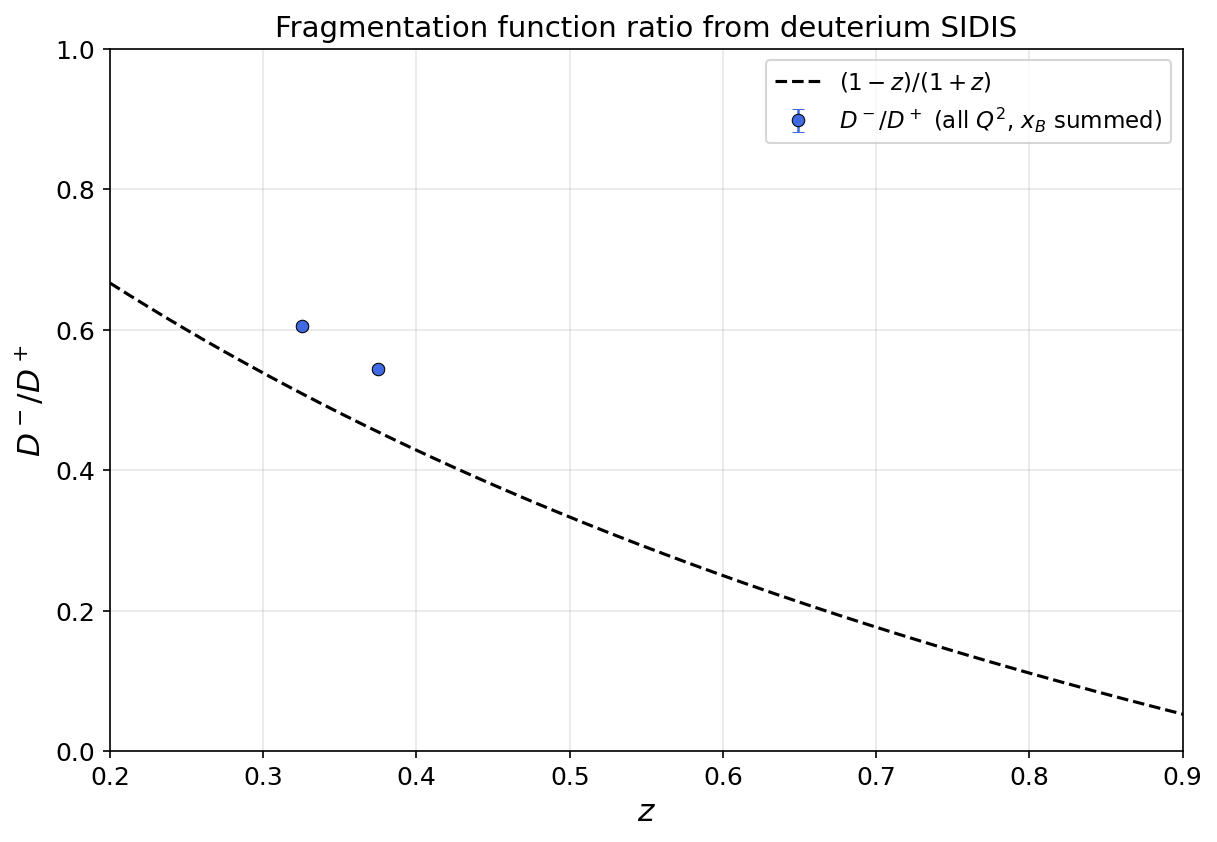

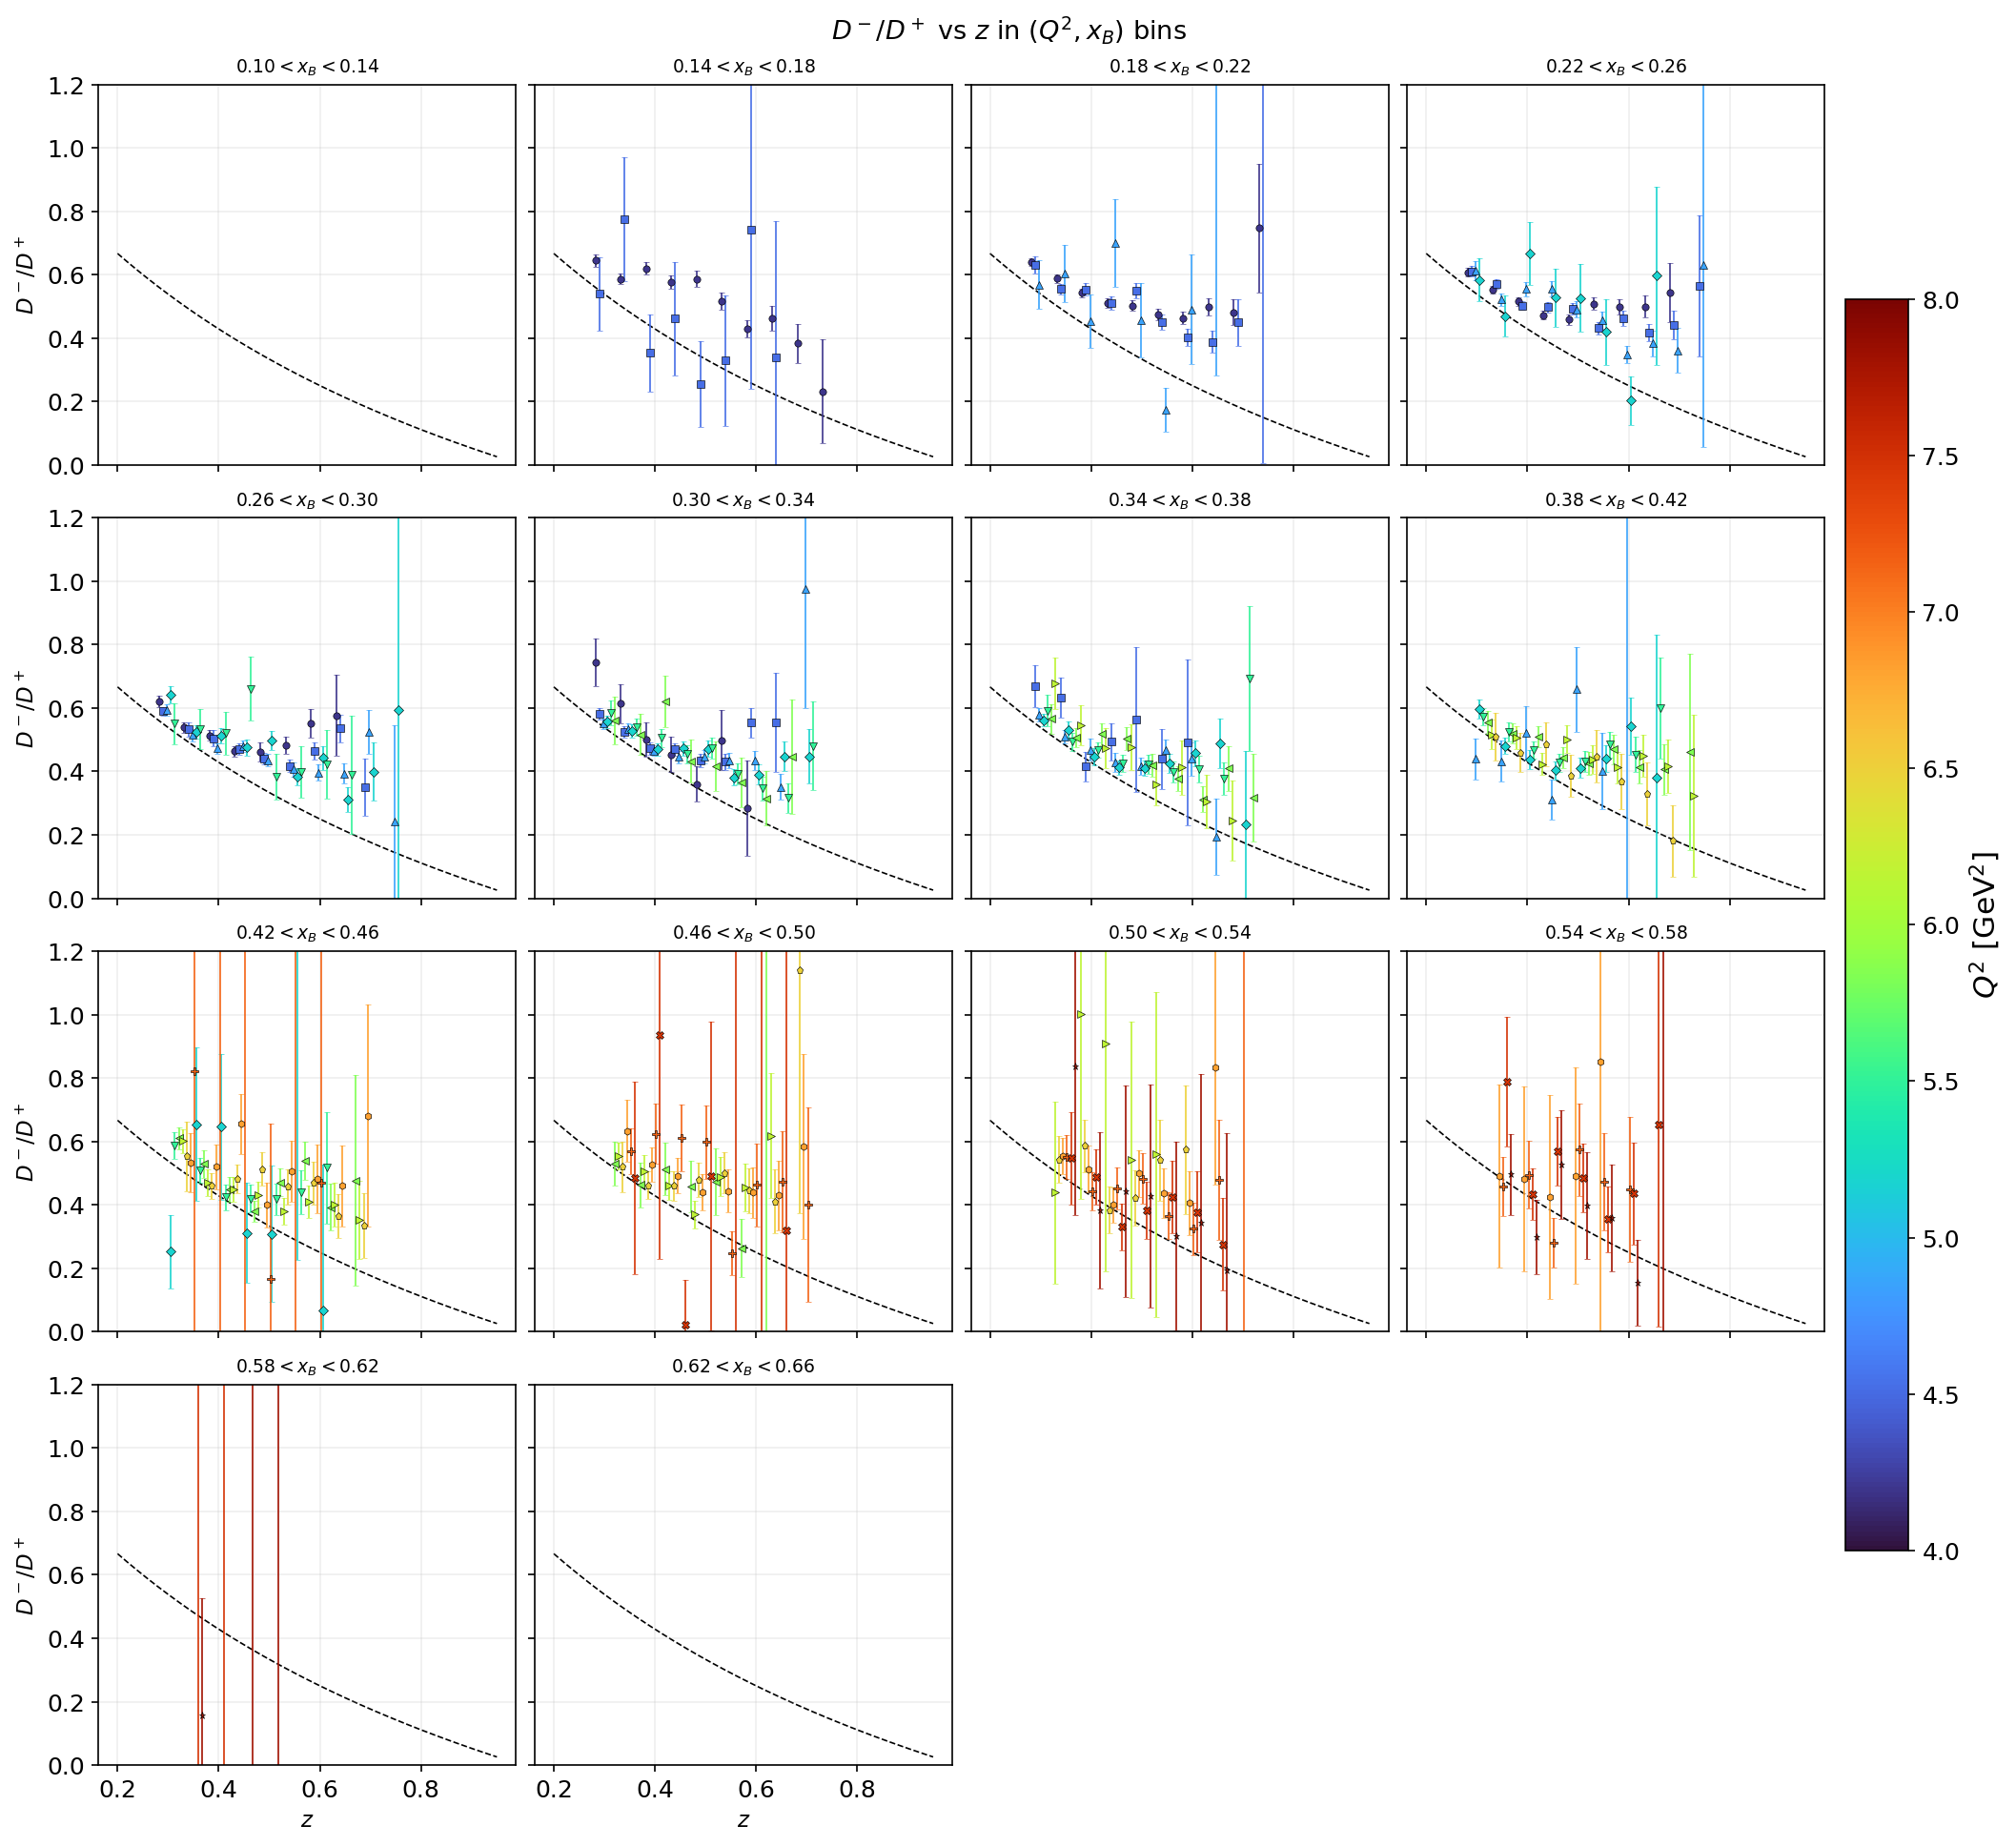

In [ ]:
# ── Plot 1a: D-/D+ vs z — z-integrated summary ──────────────────────────────
fig1, ax1 = plt.subplots(figsize=(8, 5.5), layout='constrained')

mask_D = np.isfinite(DmDp_z)
ax1.errorbar(
    z_centers[mask_D], DmDp_z[mask_D], DmDp_z_err[mask_D],
    fmt='o', color='royalblue', capsize=3, lw=1.2, capthick=1,
    markersize=6, mec='black', mew=0.5,
    label=r'$D^-/D^+$ (all $Q^2$, $x_B$ summed)'
)

z_line = np.linspace(0.2, 0.95, 300)
ax1.plot(z_line, (1 - z_line) / (1 + z_line),
         'k--', lw=1.5, label=r'$(1-z)/(1+z)$')

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$D^-/D^+$')
ax1.set_xlim(0.2, 0.9)
ax1.set_ylim(0, 1)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_title(r'Fragmentation function ratio from deuterium SIDIS')

if OUT_DIR:
    fig1.savefig(os.path.join(OUT_DIR, 'DmDp_vs_z_integrated.png'))
    fig1.savefig(os.path.join(OUT_DIR, 'DmDp_vs_z_integrated.pdf'))
plt.show()

# ── Plot 1b: D-/D+ vs z — grid of xB panels, Q2 as coloured curves ─────────
n_cols_grid = 4
n_rows_grid = int(np.ceil(BINS_XB / n_cols_grid))
cmap_q2 = plt.cm.turbo
q2_colors = cmap_q2(np.linspace(0.05, 0.95, BINS_Q2))
markers_cycle = ['o', 's', '^', 'D', 'v', '<', '>', 'p', 'h', 'P', 'X', '*']

# Small z-offsets so error bars don't pile up
z_span  = z_centers[-1] - z_centers[0] if len(z_centers) > 1 else 0.5
z_offsets = np.linspace(-(BINS_Q2-1)/2, (BINS_Q2-1)/2, BINS_Q2) * z_span * 0.012

fig1b, axs1 = plt.subplots(
    n_rows_grid, n_cols_grid, figsize=(14, n_rows_grid * 3.2),
    sharex=True, sharey=True, layout='constrained'
)

for x_idx in range(BINS_XB):
    ax = axs1.flat[x_idx]
    ax.plot(z_line, (1 - z_line) / (1 + z_line), 'k--', lw=0.8, zorder=0)
    for q_idx in range(BINS_Q2):
        vals = DmDp[q_idx, x_idx, :]
        errs = DmDp_err[q_idx, x_idx, :]
        mask = np.isfinite(vals) & (vals > 0)
        if not mask.any():
            continue
        ax.errorbar(
            z_centers[mask] + z_offsets[q_idx], vals[mask], errs[mask],
            marker=markers_cycle[q_idx % len(markers_cycle)],
            color=q2_colors[q_idx], linestyle='', capsize=1.5, lw=0.8,
            capthick=0.8, markersize=3.5, mec='black', mew=0.3
        )
    xb_lo = XB_MIN + x_idx * delta_xb
    xb_hi = xb_lo + delta_xb
    ax.set_title(rf'${xb_lo:.2f} < x_B < {xb_hi:.2f}$', fontsize=9)
    ax.set_ylim(0, 1.2)
    ax.grid(True, alpha=0.2)

for k in range(BINS_XB, n_rows_grid * n_cols_grid):
    axs1.flat[k].set_visible(False)
for ax in axs1[-1]:
    if ax.get_visible():
        ax.set_xlabel(r'$z$', fontsize=11)
for ax in axs1[:, 0]:
    ax.set_ylabel(r'$D^-/D^+$', fontsize=11)

# Colorbar for Q2
sm = plt.cm.ScalarMappable(cmap=cmap_q2,
                           norm=plt.Normalize(vmin=Q2_MIN, vmax=Q2_MAX))
sm.set_array([])
fig1b.colorbar(sm, ax=axs1[:, -1].tolist(),
               label=r'$Q^2\ \mathrm{[GeV^2]}$', shrink=0.8)
fig1b.suptitle(r'$D^-/D^+$ vs $z$ in $(Q^2, x_B)$ bins', fontsize=13)

if OUT_DIR:
    fig1b.savefig(os.path.join(OUT_DIR, 'DmDp_vs_z_binned.png'))
plt.show()

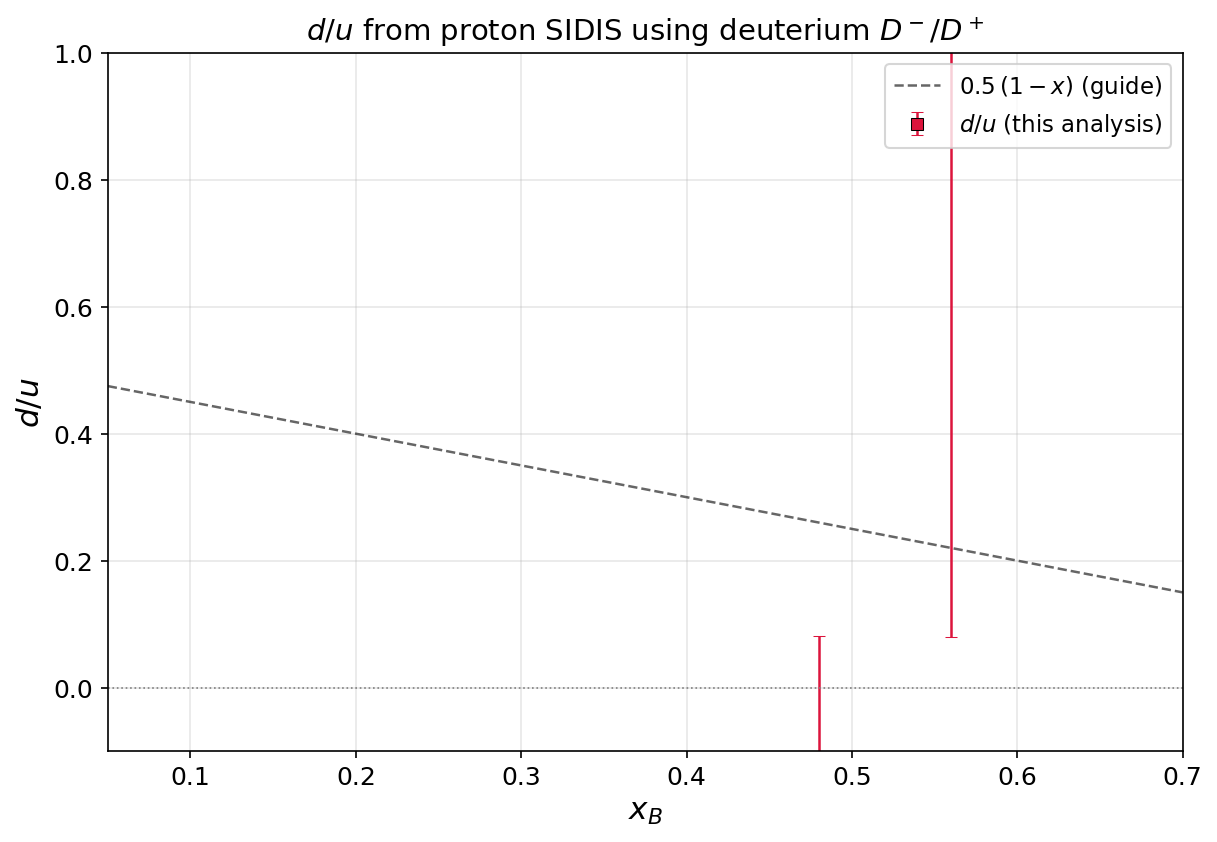

In [ ]:
# ── Plot 2: d/u vs xB ───────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(8, 5.5), layout='constrained')

# Data points (z-averaged)
mask_du = np.isfinite(du_avg)
ax2.errorbar(
    xb_centers[mask_du], du_avg[mask_du], du_avg_err[mask_du],
    fmt='s', color='crimson', capsize=3, lw=1.2, capthick=1,
    markersize=6, mec='black', mew=0.5,
    label=r'$d/u$ (this analysis)'
)

# Optional reference: perturbative-QCD inspired d/u -> 0 as x -> 1
# Simple parametrisation for visual guidance
x_ref = np.linspace(0.05, 0.7, 200)
du_ref = 0.5 * (1 - x_ref)**1.0  # approximate trend
ax2.plot(x_ref, du_ref, 'k--', lw=1.2, alpha=0.6,
         label=r'$0.5\,(1-x)$ (guide)')

ax2.axhline(0, color='gray', lw=0.8, ls=':')
ax2.set_xlabel(r'$x_B$')
ax2.set_ylabel(r'$d/u$')
ax2.set_xlim(0.05, 0.7)
ax2.set_ylim(-0.1, 1.0)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)
ax2.set_title(r'$d/u$ from proton SIDIS using deuterium $D^-/D^+$')

if OUT_DIR:
    fig2.savefig(os.path.join(OUT_DIR, 'du_vs_xB.png'))
    fig2.savefig(os.path.join(OUT_DIR, 'du_vs_xB.pdf'))
    print(f"Saved d/u plot to {OUT_DIR}/")
plt.show()

## 6b. Supplementary: $d/u$ vs $z$ in $x_B$ Bins

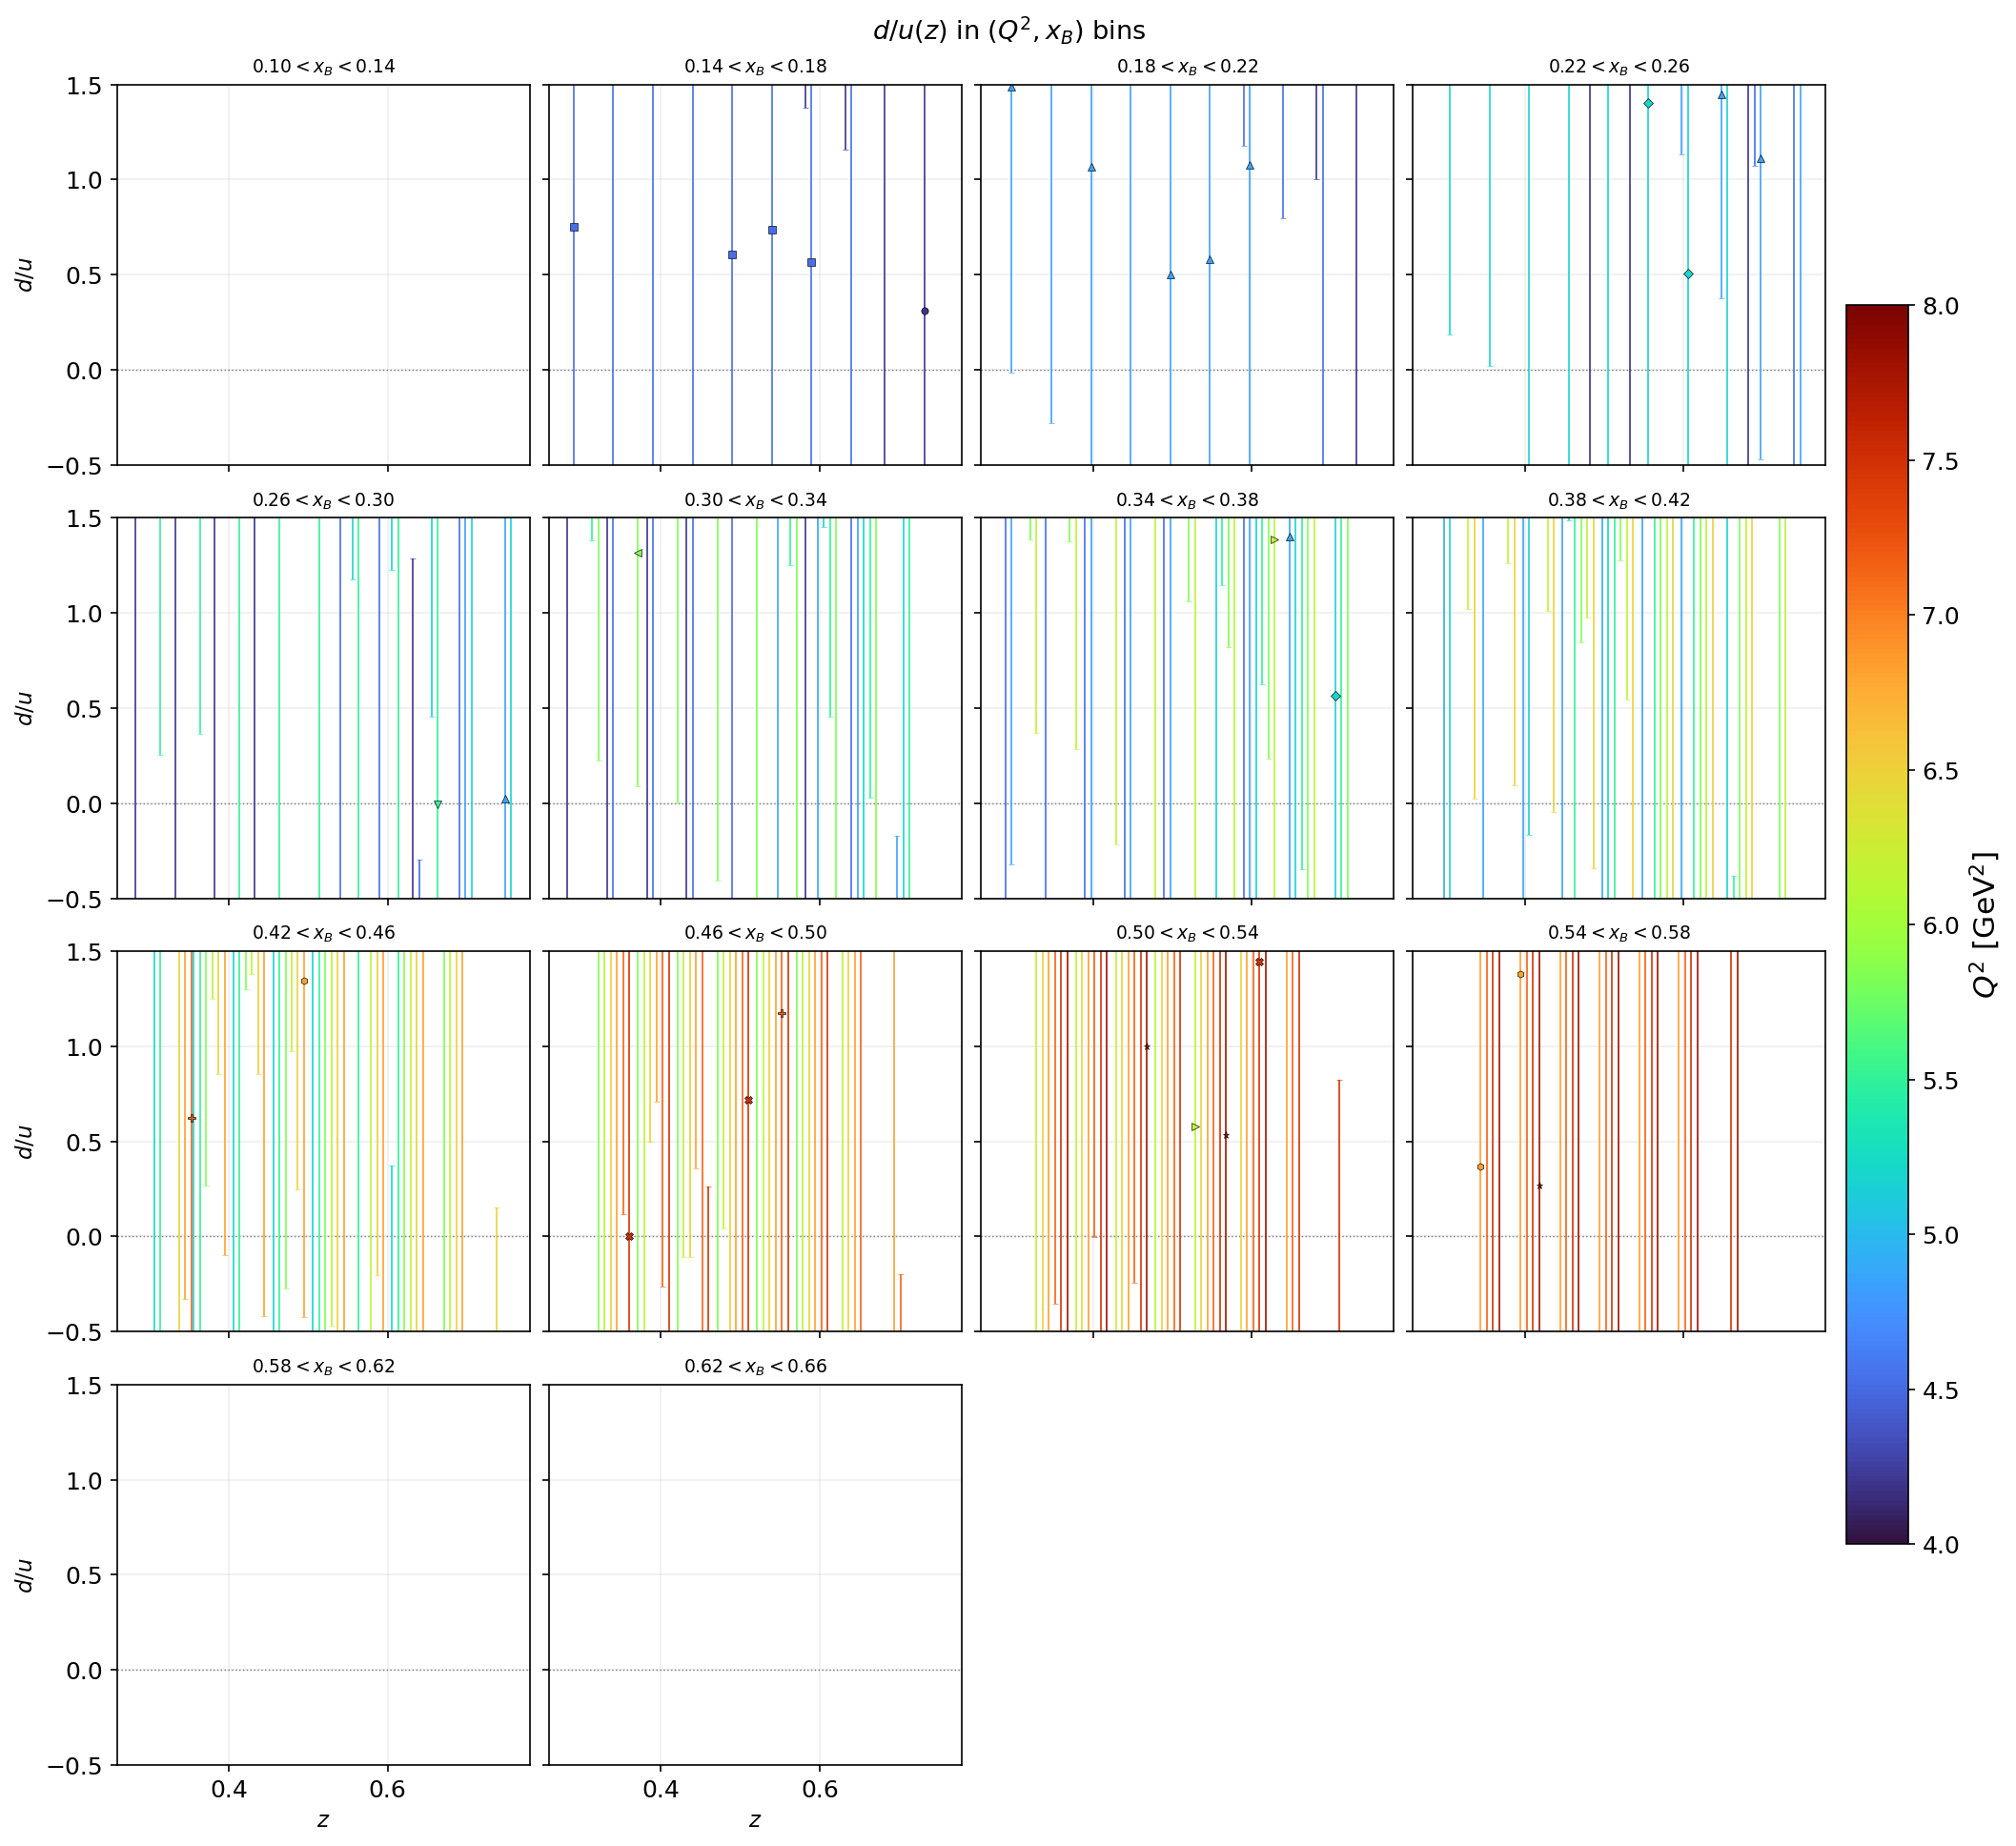

In [ ]:
# ── Supplementary: d/u vs z in xB panels, Q2 as coloured curves ─────────────
fig3, axs3 = plt.subplots(
    n_rows_grid, n_cols_grid, figsize=(14, n_rows_grid * 3.2),
    sharex=True, sharey=True, layout='constrained'
)

for x_idx in range(BINS_XB):
    ax = axs3.flat[x_idx]
    ax.axhline(0, color='gray', lw=0.7, ls=':')
    for q_idx in range(BINS_Q2):
        vals = du[q_idx, x_idx, :]
        errs = du_err[q_idx, x_idx, :]
        mask = np.isfinite(vals)
        if not mask.any():
            continue
        ax.errorbar(
            z_centers[mask] + z_offsets[q_idx], vals[mask], errs[mask],
            marker=markers_cycle[q_idx % len(markers_cycle)],
            color=q2_colors[q_idx], linestyle='', capsize=1.5, lw=0.8,
            capthick=0.8, markersize=3.5, mec='black', mew=0.3
        )
    xb_lo = XB_MIN + x_idx * delta_xb
    xb_hi = xb_lo + delta_xb
    ax.set_title(rf'${xb_lo:.2f} < x_B < {xb_hi:.2f}$', fontsize=9)
    ax.set_ylim(-0.5, 1.5)
    ax.grid(True, alpha=0.2)

for k in range(BINS_XB, n_rows_grid * n_cols_grid):
    axs3.flat[k].set_visible(False)
for ax in axs3[-1]:
    if ax.get_visible():
        ax.set_xlabel(r'$z$', fontsize=11)
for ax in axs3[:, 0]:
    ax.set_ylabel(r'$d/u$', fontsize=11)

sm3 = plt.cm.ScalarMappable(cmap=cmap_q2,
                            norm=plt.Normalize(vmin=Q2_MIN, vmax=Q2_MAX))
sm3.set_array([])
fig3.colorbar(sm3, ax=axs3[:, -1].tolist(),
              label=r'$Q^2\ \mathrm{[GeV^2]}$', shrink=0.8)
fig3.suptitle(r'$d/u(z)$ in $(Q^2, x_B)$ bins', fontsize=13)

if OUT_DIR:
    fig3.savefig(os.path.join(OUT_DIR, 'du_vs_z_binned.png'))
plt.show()

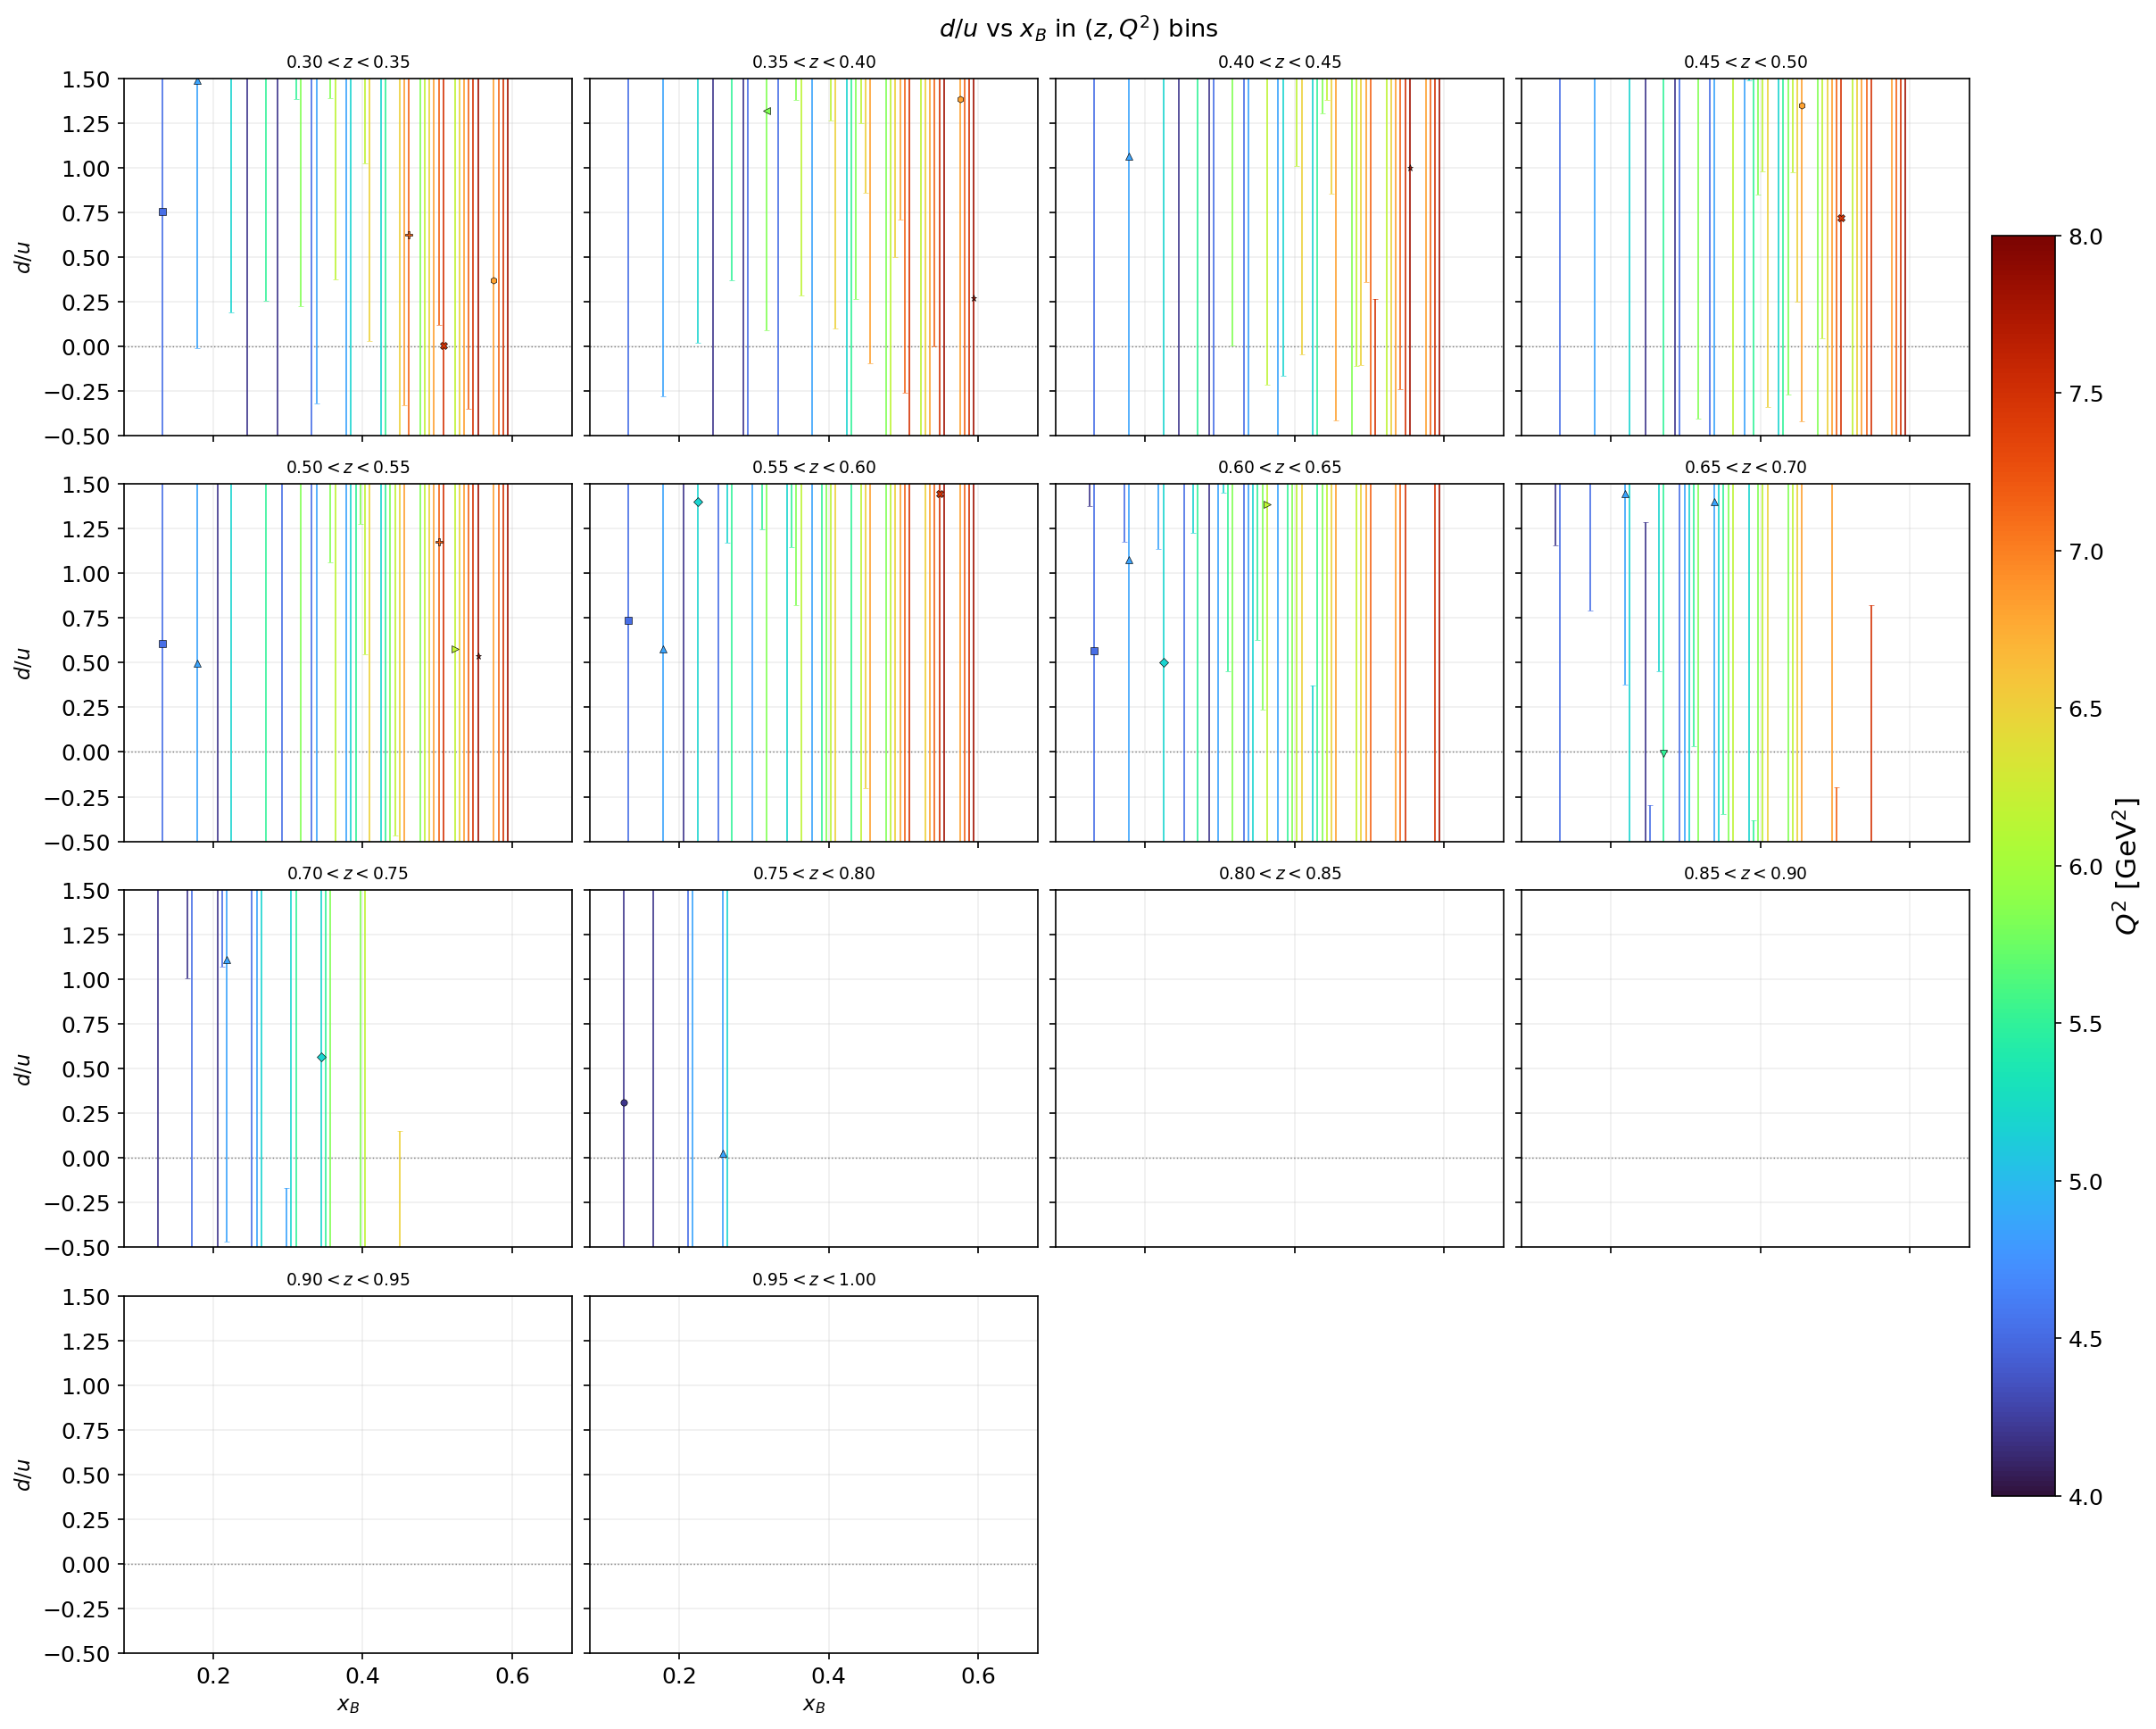

In [ ]:
# ── Plot 3: d/u vs xB — grid of z panels, Q2 as coloured curves ─────────────
# du has shape (BINS_Q2, BINS_XB, BINS_Z).
# Each panel = one z bin.  Curves = Q2 bins.  x-axis = xB.

# Infer z bin edges from centres
if len(z_centers) > 1:
    dz = z_centers[1] - z_centers[0]
else:
    dz = 0.05
z_lo_arr = z_centers - dz / 2
z_hi_arr = z_centers + dz / 2

n_z = len(z_centers)
n_cols_z = 4
n_rows_z = int(np.ceil(n_z / n_cols_z))

# Small xB-offsets so error bars don't pile up
xb_span   = xb_centers[-1] - xb_centers[0] if len(xb_centers) > 1 else 0.1
xb_offsets = np.linspace(-(BINS_Q2-1)/2, (BINS_Q2-1)/2, BINS_Q2) * xb_span * 0.012

fig4, axs4 = plt.subplots(
    n_rows_z, n_cols_z, figsize=(16, n_rows_z * 3.2),
    sharex=True, sharey=True, layout='constrained'
)

for z_idx in range(n_z):
    ax = axs4.flat[z_idx]
    ax.axhline(0, color='gray', lw=0.7, ls=':')
    for q_idx in range(BINS_Q2):
        vals = du[q_idx, :, z_idx]         # shape (BINS_XB,)
        errs = du_err[q_idx, :, z_idx]
        mask = np.isfinite(vals)
        if not mask.any():
            continue
        ax.errorbar(
            xb_centers[mask] + xb_offsets[q_idx], vals[mask], errs[mask],
            marker=markers_cycle[q_idx % len(markers_cycle)],
            color=q2_colors[q_idx], linestyle='', capsize=1.5, lw=0.8,
            capthick=0.8, markersize=3.5, mec='black', mew=0.3
        )
    ax.set_title(rf'${z_lo_arr[z_idx]:.2f} < z < {z_hi_arr[z_idx]:.2f}$', fontsize=9)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlim(XB_MIN - 0.02, XB_MAX + 0.02)
    ax.grid(True, alpha=0.2)

# Hide unused panels
for k in range(n_z, n_rows_z * n_cols_z):
    axs4.flat[k].set_visible(False)

for ax in axs4[-1]:
    if ax.get_visible():
        ax.set_xlabel(r'$x_B$', fontsize=11)
for ax in axs4[:, 0]:
    ax.set_ylabel(r'$d/u$', fontsize=11)

# Colorbar for Q2
sm4 = plt.cm.ScalarMappable(cmap=cmap_q2,
                            norm=plt.Normalize(vmin=Q2_MIN, vmax=Q2_MAX))
sm4.set_array([])
fig4.colorbar(sm4, ax=axs4[:, -1].tolist(),
              label=r'$Q^2\ \mathrm{[GeV^2]}$', shrink=0.8)
fig4.suptitle(r'$d/u$ vs $x_B$ in $(z, Q^2)$ bins', fontsize=13)

if OUT_DIR:
    fig4.savefig(os.path.join(OUT_DIR, 'du_vs_xB_binned.png'))
plt.show()

In [ ]:
print("\nAnalysis complete.")


Analysis complete.
